<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-danborghi/blob/main/EDA_WINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados — Wine Quality

Este notebook realiza uma análise exploratória de dados, conhecida como **EDA — Exploratory Data Analysis**, utilizando os datasets de qualidade de vinhos tintos e brancos.

O objetivo é compreender melhor a estrutura dos dados, comparar os dois tipos de vinho e identificar possíveis relações entre as variáveis físico-químicas e a nota de qualidade.

**Bibliotecas utilizadas:** apenas `pandas` e `matplotlib`.

## 1. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas permitidas para o trabalho:

- `pandas`: manipulação e análise de dados;
- `matplotlib`: criação de gráficos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregamento dos datasets

Os arquivos utilizados são:

- `winequality-red.csv`: dados de vinhos tintos;
- `winequality-white.csv`: dados de vinhos brancos.


Observação: os arquivos usam `;` como separador, por isso utilizamos `sep=';'`.

In [ ]:
df_red = pd.read_csv('/content/winequality-red.csv', sep=';')
df_white = pd.read_csv('/content/winequality-white.csv', sep=';')

print("Dimensão do dataset de vinho tinto:", df_red.shape)
print("Dimensão do dataset de vinho branco:", df_white.shape)

Dimensão do dataset de vinho tinto: (1599, 12)
Dimensão do dataset de vinho branco: (4898, 12)


## 3. Visualização inicial dos datasets

In [ ]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 4. Verificação das colunas

Como os dois datasets possuem as mesmas colunas, o procedimento correto é fazer uma **concatenação** usando `pd.concat()`.

Não utilizamos `merge`, pois não existe uma chave comum para cruzar os dados. Neste caso, queremos apenas empilhar os registros dos vinhos tintos e brancos em um único dataframe.

In [ ]:
print("Colunas do dataset tinto:")
print(df_red.columns)

print("\nColunas do dataset branco:")
print(df_white.columns)

print("\nAs colunas são iguais?")
print(df_red.columns.equals(df_white.columns))

Colunas do dataset tinto:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Colunas do dataset branco:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

As colunas são iguais?
True


## 5. Criação da coluna `tipo_vinho`

Antes de juntar os dados, criamos uma nova coluna chamada `tipo_vinho`.

Essa coluna será usada para diferenciar os registros de vinho tinto e vinho branco depois da união dos datasets.

In [ ]:
df_red['tipo_vinho'] = 'Tinto'
df_white['tipo_vinho'] = 'Branco'

## 6. União dos datasets

Agora os dois datasets serão unidos em um único dataframe.

O parâmetro `ignore_index=True` reorganiza o índice do dataframe final.

In [ ]:
df = pd.concat([df_red, df_white], ignore_index=True)

print("Dimensão do dataset final:", df.shape)

df.head()

Dimensão do dataset final: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo_vinho
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto


## 7. Informações gerais do dataset

Nesta etapa, analisamos:

- quantidade de linhas e colunas;
- nomes das colunas;
- tipos de dados;
- presença de valores nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo_vinho            6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## 8. Estatísticas descritivas

A função `describe()` apresenta medidas como média, desvio padrão, valor mínimo, quartis e valor máximo das variáveis numéricas.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## 9. Verificação de valores nulos e duplicados

Aqui verificamos se existem dados ausentes ou linhas repetidas.

In [ ]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nQuantidade de linhas duplicadas:")
print(df.duplicated().sum())

Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
tipo_vinho              0
dtype: int64

Quantidade de linhas duplicadas:
1177


## 10. Quantidade de vinhos por tipo

Este gráfico mostra a quantidade de registros de vinho tinto e vinho branco presentes no dataset.

tipo_vinho
Branco    4898
Tinto     1599
Name: count, dtype: int64


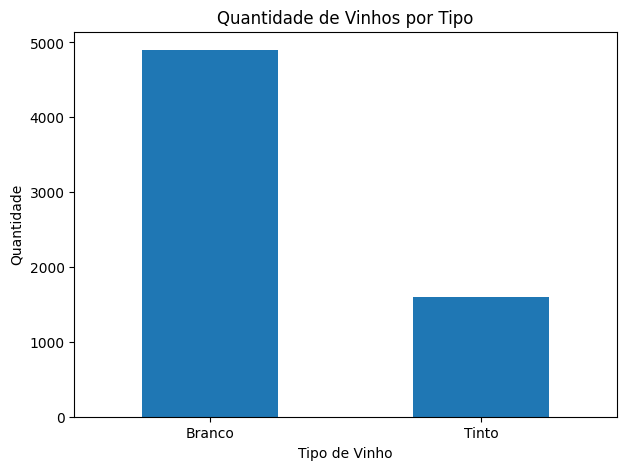

In [ ]:
quantidade_tipo = df['tipo_vinho'].value_counts()

print(quantidade_tipo)

plt.figure(figsize=(7, 5))
quantidade_tipo.plot(kind='bar')

plt.title('Quantidade de Vinhos por Tipo')
plt.xlabel('Tipo de Vinho')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)

plt.show()

## 11. Distribuição das notas de qualidade

A coluna `quality` representa a nota de qualidade do vinho.

Neste gráfico, visualizamos a frequência de cada nota.

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


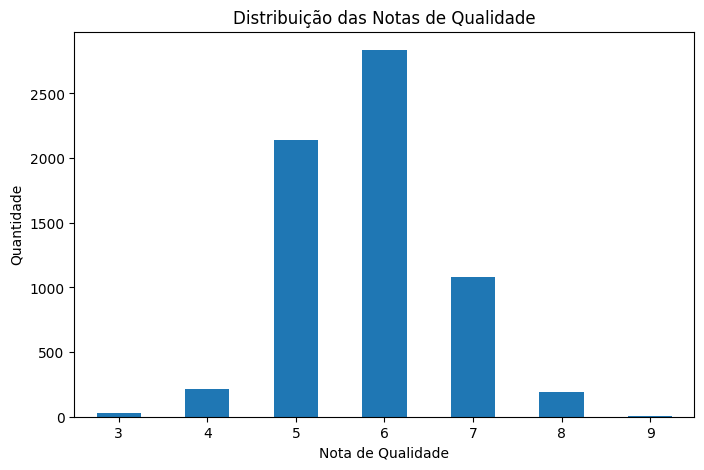

In [ ]:
qualidade = df['quality'].value_counts().sort_index()

print(qualidade)

plt.figure(figsize=(8, 5))
qualidade.plot(kind='bar')

plt.title('Distribuição das Notas de Qualidade')
plt.xlabel('Nota de Qualidade')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)

plt.show()

## 12. Comparação da qualidade por tipo de vinho

Nesta etapa, comparamos a distribuição das notas entre vinhos tintos e brancos.

In [ ]:
qualidade_tipo = pd.crosstab(df['quality'], df['tipo_vinho'])

qualidade_tipo

tipo_vinho,Branco,Tinto
quality,,
3,20,10
4,163,53
5,1457,681
6,2198,638
7,880,199
8,175,18
9,5,0


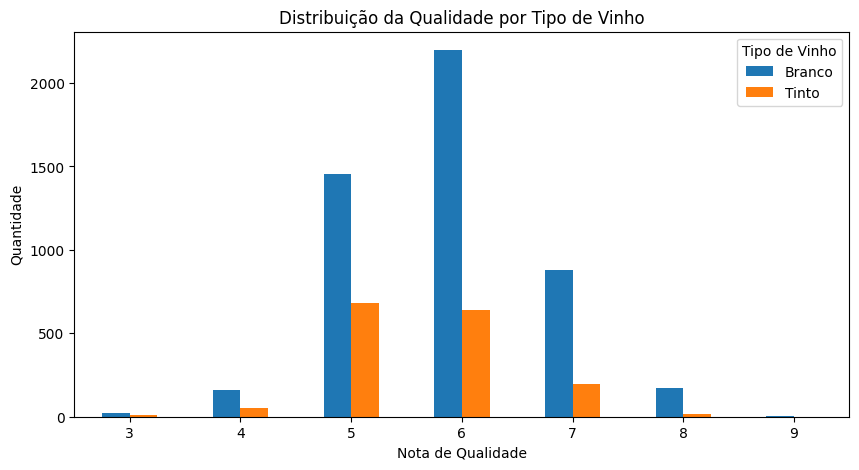

In [ ]:
qualidade_tipo.plot(kind='bar', figsize=(10, 5))

plt.title('Distribuição da Qualidade por Tipo de Vinho')
plt.xlabel('Nota de Qualidade')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(title='Tipo de Vinho')

plt.show()

## 13. Média de qualidade por tipo de vinho

As médias são bem equivalentes, a maior discrepância é por conta das quantidades de dados do dataset.

tipo_vinho
Branco    5.877909
Tinto     5.636023
Name: quality, dtype: float64


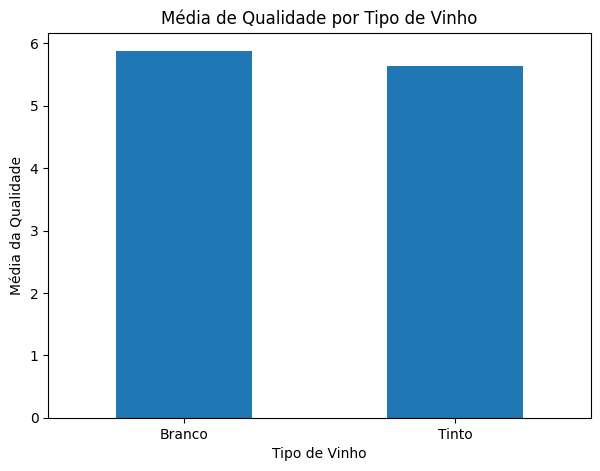

In [ ]:
media_qualidade_tipo = df.groupby('tipo_vinho')['quality'].mean().sort_values(ascending=False)

print(media_qualidade_tipo)

plt.figure(figsize=(7, 5))
media_qualidade_tipo.plot(kind='bar')

plt.title('Média de Qualidade por Tipo de Vinho')
plt.xlabel('Tipo de Vinho')
plt.ylabel('Média da Qualidade')
plt.xticks(rotation=0)

plt.show()

## 14. Distribuição do teor alcoólico por tipo de vinho

O teor alcoólico é uma variável importante na análise da qualidade dos vinhos.

Neste gráfico, comparamos a distribuição do álcool entre vinhos tintos e brancos.

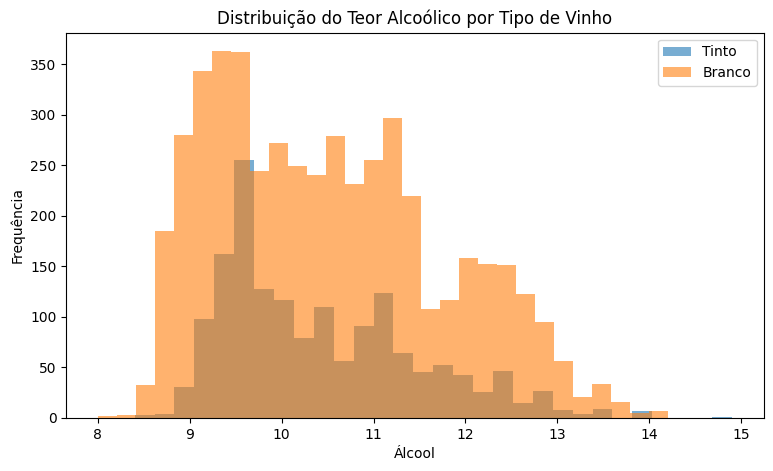

In [ ]:
plt.figure(figsize=(9, 5))

for tipo in df['tipo_vinho'].unique():
    dados = df[df['tipo_vinho'] == tipo]['alcohol']
    plt.hist(dados, bins=30, alpha=0.6, label=tipo)

plt.title('Distribuição do Teor Alcoólico por Tipo de Vinho')
plt.xlabel('Álcool')
plt.ylabel('Frequência')
plt.legend()

plt.show()

## 15. Relação entre qualidade e teor alcoólico

Este gráfico mostra a média de álcool para cada nota de qualidade.

A ideia é verificar se vinhos com notas mais altas tendem a apresentar maior teor alcoólico.

quality
3    10.215000
4    10.180093
5     9.837783
6    10.587553
7    11.386006
8    11.678756
9    12.180000
Name: alcohol, dtype: float64


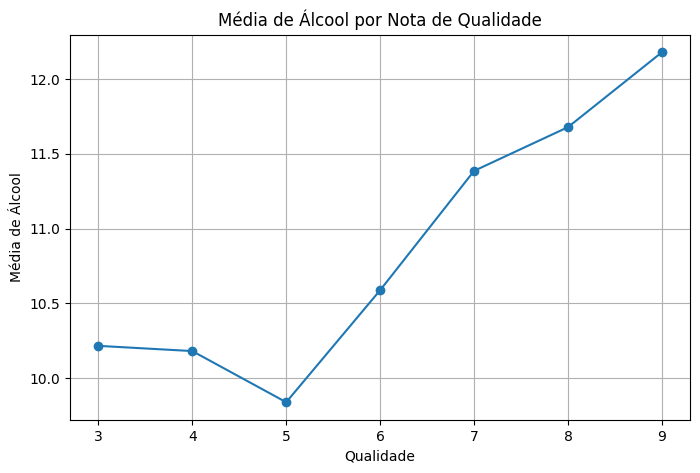

In [ ]:
alcool_por_qualidade = df.groupby('quality')['alcohol'].mean()

print(alcool_por_qualidade)

plt.figure(figsize=(8, 5))
alcool_por_qualidade.plot(kind='line', marker='o')

plt.title('Média de Álcool por Nota de Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Média de Álcool')
plt.grid(True)

plt.show()

## 16. Boxplot do álcool por nota de qualidade

O boxplot permite observar a dispersão dos valores de álcool em cada nota de qualidade.

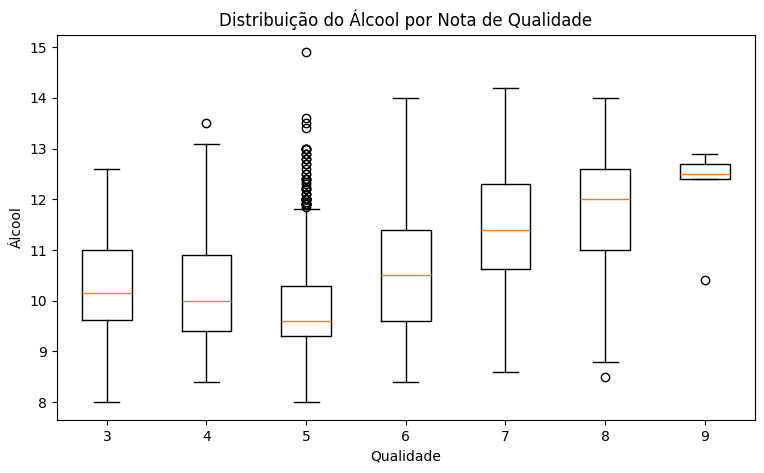

In [ ]:
qualidades = sorted(df['quality'].unique())

dados_boxplot = [
    df[df['quality'] == qualidade]['alcohol']
    for qualidade in qualidades
]

plt.figure(figsize=(9, 5))
plt.boxplot(dados_boxplot, tick_labels=qualidades)

plt.title('Distribuição do Álcool por Nota de Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Álcool')

plt.show()

## 17. Acidez volátil por qualidade

A acidez volátil pode influenciar negativamente a percepção da qualidade do vinho.

Nesta etapa, analisamos a média de acidez volátil para cada nota de qualidade.

quality
3    0.517000
4    0.457963
5    0.389614
6    0.313863
7    0.288800
8    0.291010
9    0.298000
Name: volatile acidity, dtype: float64


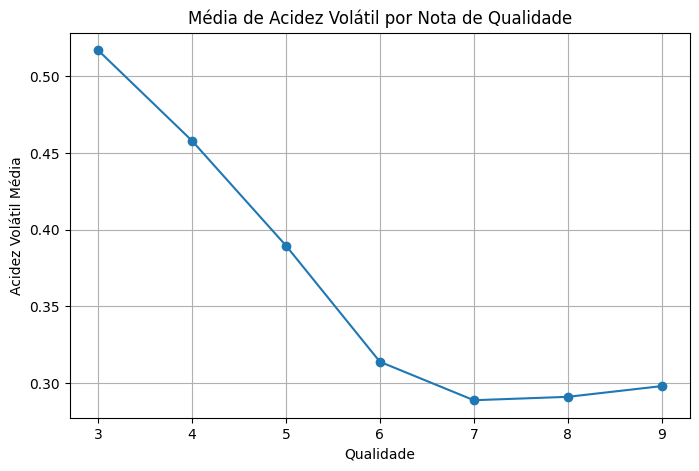

In [ ]:
acidez_por_qualidade = df.groupby('quality')['volatile acidity'].mean()

print(acidez_por_qualidade)

plt.figure(figsize=(8, 5))
acidez_por_qualidade.plot(kind='line', marker='o')

plt.title('Média de Acidez Volátil por Nota de Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Acidez Volátil Média')
plt.grid(True)

plt.show()

## 18. Açúcar residual por tipo de vinho

O açúcar residual é uma variável que costuma diferenciar bastante os vinhos tintos e brancos.

Este gráfico compara a distribuição do açúcar residual entre os dois tipos.

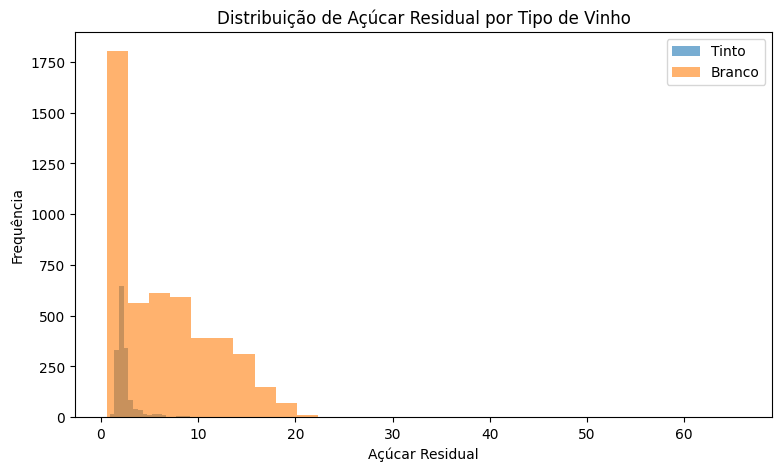

In [ ]:
plt.figure(figsize=(9, 5))

for tipo in df['tipo_vinho'].unique():
    dados = df[df['tipo_vinho'] == tipo]['residual sugar']
    plt.hist(dados, bins=30, alpha=0.6, label=tipo)

plt.title('Distribuição de Açúcar Residual por Tipo de Vinho')
plt.xlabel('Açúcar Residual')
plt.ylabel('Frequência')
plt.legend()

plt.show()

## 19. Relação entre açúcar residual e densidade

A densidade pode estar relacionada à quantidade de açúcar residual presente no vinho.

Neste gráfico de dispersão, analisamos a relação entre essas duas variáveis.

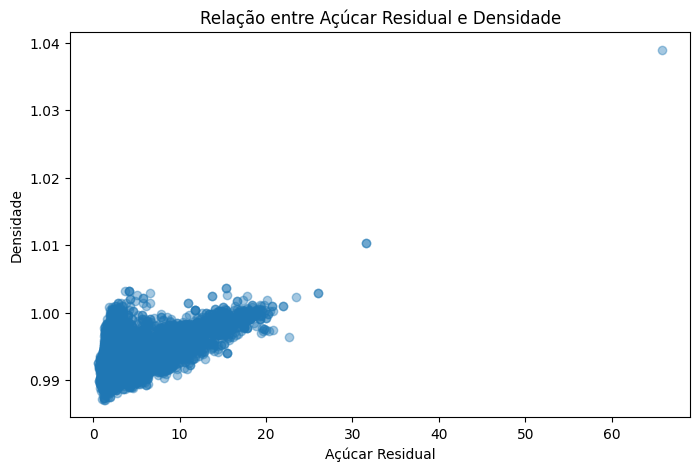

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['residual sugar'], df['density'], alpha=0.4)

plt.title('Relação entre Açúcar Residual e Densidade')
plt.xlabel('Açúcar Residual')
plt.ylabel('Densidade')

plt.show()

## 20. Relação entre álcool e qualidade

Este gráfico de dispersão permite observar a distribuição dos registros considerando qualidade e teor alcoólico.

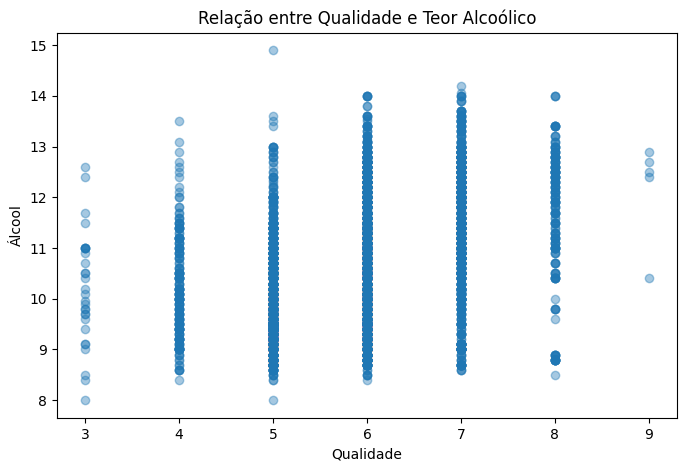

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['quality'], df['alcohol'], alpha=0.4)

plt.title('Relação entre Qualidade e Teor Alcoólico')
plt.xlabel('Qualidade')
plt.ylabel('Álcool')

plt.show()

## 21. Matriz de correlação

A matriz de correlação ajuda a identificar relações entre as variáveis numéricas.

Valores próximos de `1` indicam correlação positiva forte.  
Valores próximos de `-1` indicam correlação negativa forte.  
Valores próximos de `0` indicam baixa correlação linear.

In [ ]:
corr = df.drop(columns=['tipo_vinho']).corr()

corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


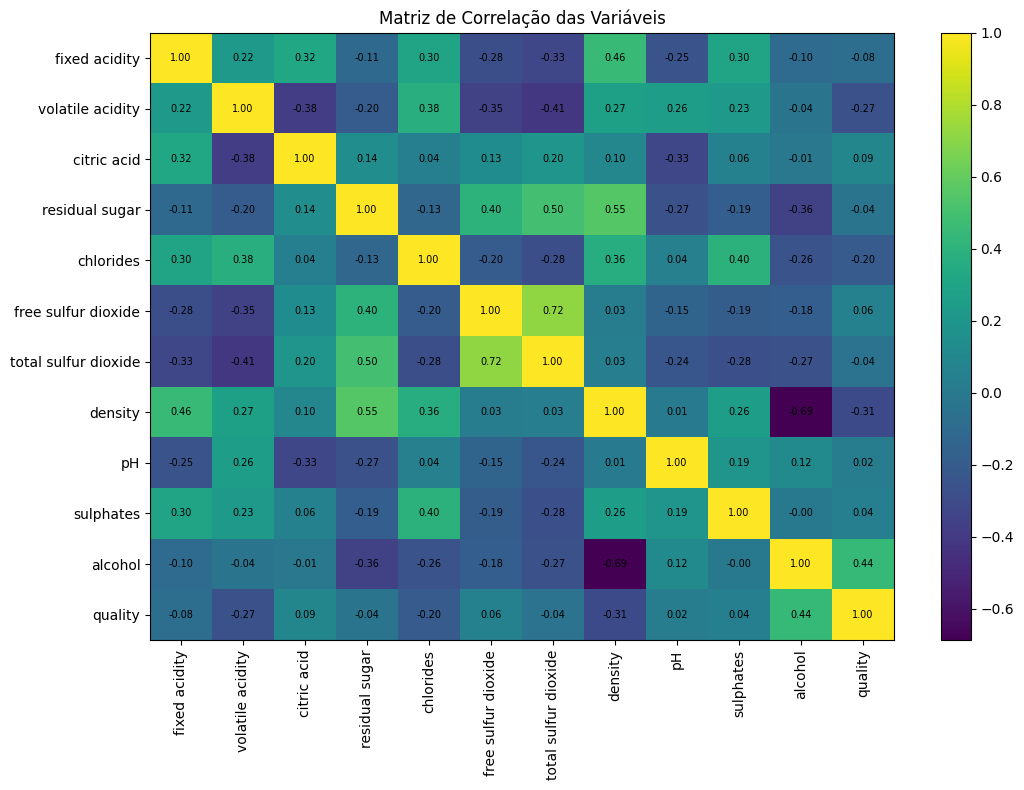

In [ ]:
plt.figure(figsize=(11, 8))

plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Matriz de Correlação das Variáveis')

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 22. Correlação das variáveis com a qualidade

Nesta etapa, ordenamos as variáveis de acordo com a correlação com a coluna `quality`.

In [ ]:
correlacao_quality = corr['quality'].sort_values(ascending=False)

correlacao_quality

,quality
quality,1.000000
alcohol,0.444319
citric acid,0.085532
free sulfur dioxide,0.055463
sulphates,0.038485
pH,0.019506
residual sugar,-0.036980
total sulfur dioxide,-0.041385
fixed acidity,-0.076743
chlorides,-0.200666


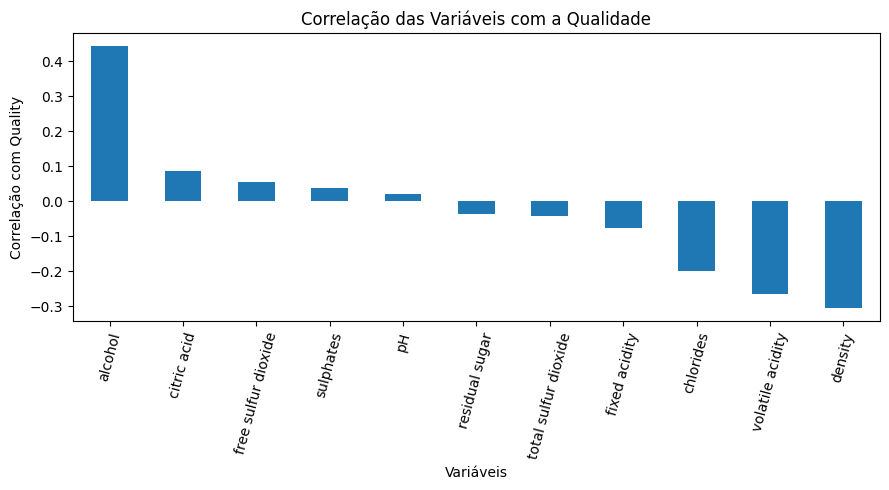

In [ ]:
correlacao_quality_sem_quality = correlacao_quality.drop('quality')

plt.figure(figsize=(9, 5))
correlacao_quality_sem_quality.plot(kind='bar')

plt.title('Correlação das Variáveis com a Qualidade')
plt.xlabel('Variáveis')
plt.ylabel('Correlação com Quality')
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

## 23. Comparação das médias por tipo de vinho

Agora comparamos as médias das variáveis numéricas entre vinhos tintos e brancos.

In [ ]:
medias_por_tipo = df.groupby('tipo_vinho').mean(numeric_only=True)

medias_por_tipo

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
tipo_vinho,,,,,,,,,,,,
Branco,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
Tinto,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023


## 24. Comparação visual de algumas variáveis

Selecionamos algumas variáveis importantes para comparar os valores médios entre vinhos tintos e brancos.

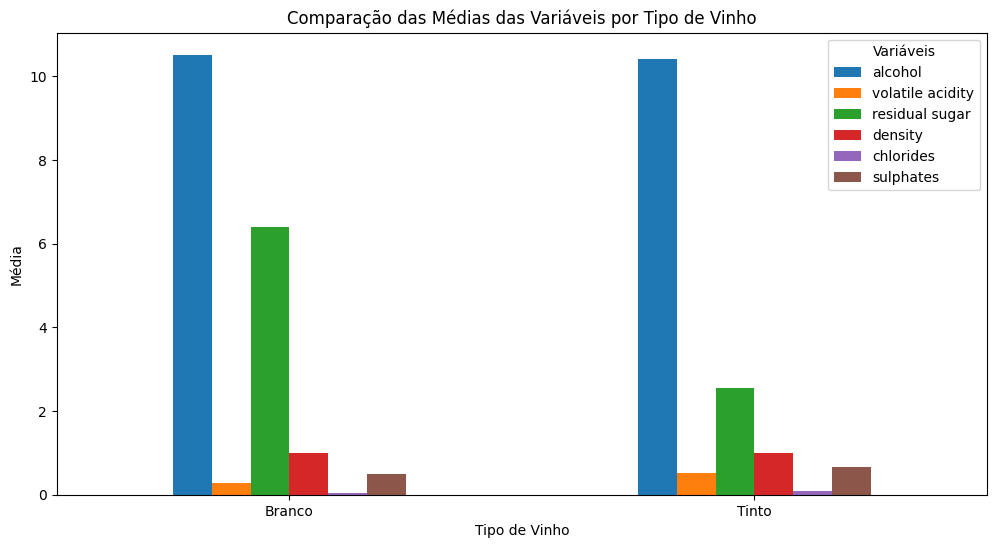

In [ ]:
variaveis = [
    'alcohol',
    'volatile acidity',
    'residual sugar',
    'density',
    'chlorides',
    'sulphates'
]

medias_por_tipo[variaveis].plot(kind='bar', figsize=(12, 6))

plt.title('Comparação das Médias das Variáveis por Tipo de Vinho')
plt.xlabel('Tipo de Vinho')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.legend(title='Variáveis')

plt.show()

## 25. Criação de categorias de qualidade

Para facilitar a interpretação, podemos transformar a nota numérica em três categorias:

- `Baixa`: qualidade menor ou igual a 5;
- `Média`: qualidade igual a 6;
- `Alta`: qualidade maior ou igual a 7.

In [ ]:
def categorizar_qualidade(nota):
    if nota <= 5:
        return 'Baixa'
    elif nota == 6:
        return 'Média'
    else:
        return 'Alta'

df['categoria_qualidade'] = df['quality'].apply(categorizar_qualidade)

df[['quality', 'categoria_qualidade']].head()

,quality,categoria_qualidade
0,5,Baixa
1,5,Baixa
2,5,Baixa
3,6,Média
4,5,Baixa


## 26. Categoria de qualidade por tipo de vinho

Este gráfico mostra como as categorias de qualidade estão distribuídas entre vinhos tintos e brancos.

In [ ]:
categoria_tipo = pd.crosstab(df['categoria_qualidade'], df['tipo_vinho'])

categoria_tipo

tipo_vinho,Branco,Tinto
categoria_qualidade,,
Alta,1060,217
Baixa,1640,744
Média,2198,638


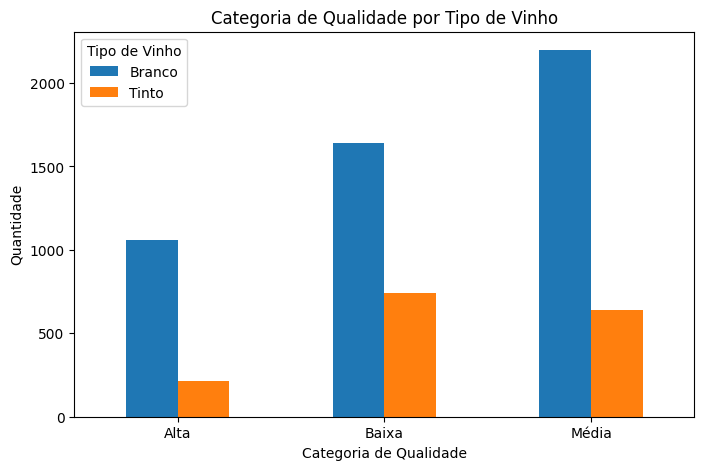

In [ ]:
categoria_tipo.plot(kind='bar', figsize=(8, 5))

plt.title('Categoria de Qualidade por Tipo de Vinho')
plt.xlabel('Categoria de Qualidade')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(title='Tipo de Vinho')

plt.show()

## 27. Relatório final automático

Nesta célula, geramos um pequeno resumo textual com alguns resultados do dataset.

In [ ]:
total_registros = len(df)
total_tintos = len(df[df['tipo_vinho'] == 'Tinto'])
total_brancos = len(df[df['tipo_vinho'] == 'Branco'])

media_tinto = df[df['tipo_vinho'] == 'Tinto']['quality'].mean()
media_branco = df[df['tipo_vinho'] == 'Branco']['quality'].mean()

melhor_correlacao_positiva = correlacao_quality_sem_quality.sort_values(ascending=False).index[0]
valor_melhor_correlacao_positiva = correlacao_quality_sem_quality.sort_values(ascending=False).iloc[0]

melhor_correlacao_negativa = correlacao_quality_sem_quality.sort_values(ascending=True).index[0]
valor_melhor_correlacao_negativa = correlacao_quality_sem_quality.sort_values(ascending=True).iloc[0]

print("RELATÓRIO FINAL DA ANÁLISE EXPLORATÓRIA")
print("-" * 50)
print(f"O dataset final possui {total_registros} registros.")
print(f"Quantidade de vinhos tintos: {total_tintos}.")
print(f"Quantidade de vinhos brancos: {total_brancos}.")
print(f"Média de qualidade dos vinhos tintos: {media_tinto:.2f}.")
print(f"Média de qualidade dos vinhos brancos: {media_branco:.2f}.")
print(f"Variável com maior correlação positiva com quality: {melhor_correlacao_positiva} ({valor_melhor_correlacao_positiva:.2f}).")
print(f"Variável com maior correlação negativa com quality: {melhor_correlacao_negativa} ({valor_melhor_correlacao_negativa:.2f}).")

RELATÓRIO FINAL DA ANÁLISE EXPLORATÓRIA
--------------------------------------------------
O dataset final possui 6497 registros.
Quantidade de vinhos tintos: 1599.
Quantidade de vinhos brancos: 4898.
Média de qualidade dos vinhos tintos: 5.64.
Média de qualidade dos vinhos brancos: 5.88.
Variável com maior correlação positiva com quality: alcohol (0.44).
Variável com maior correlação negativa com quality: density (-0.31).


## 28. Conclusão

A análise exploratória foi realizada a partir da união dos datasets de vinho tinto e vinho branco. Para permitir a comparação entre os dois grupos, foi criada a coluna `tipo_vinho`, indicando a origem de cada registro.

O dataset final possui registros de vinhos tintos e brancos com variáveis físico-químicas, como acidez, açúcar residual, cloretos, densidade, pH, sulfatos, álcool e a nota de qualidade.

Durante a análise, foi possível observar que a maior parte dos vinhos possui nota concentrada em valores intermediários, principalmente entre 5 e 6. Também foi identificado que os vinhos brancos aparecem em maior quantidade no dataset e apresentam uma média de qualidade ligeiramente superior à dos vinhos tintos.

Entre as variáveis analisadas, o teor alcoólico demonstrou uma relação positiva com a qualidade, indicando que vinhos com maior teor de álcool tendem a receber notas mais altas. Por outro lado, variáveis como acidez volátil, densidade e cloretos apresentaram relação negativa com a qualidade, sugerindo que valores mais altos dessas características podem estar associados a avaliações inferiores.

A comparação entre vinhos tintos e brancos também mostrou diferenças importantes. Os vinhos brancos possuem, em média, maior açúcar residual, enquanto os tintos apresentam maiores valores médios de acidez volátil, cloretos e sulfatos.

In [ ]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

df_model["good_quality"] = (df_model["quality"] >= 7).astype(int)

X = df_model.drop(
    columns=["quality", "good_quality", "categoria_qualidade"],
    errors="ignore"
)

y = df_model["good_quality"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

print("\nDistribuição da variável alvo:")
print(y.value_counts())

Tamanho do treino: (4872, 12)
Tamanho do teste: (1625, 12)

Distribuição da variável alvo:
good_quality
0    5220
1    1277
Name: count, dtype: int64


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline = DummyClassifier(strategy="most_frequent", random_state=42)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Acurácia baseline: 0.8036923076923077

Matriz de confusão:
[[1306    0]
 [ 319    0]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1306
           1       0.00      0.00      0.00       319

    accuracy                           0.80      1625
   macro avg       0.40      0.50      0.45      1625
weighted avg       0.65      0.80      0.72      1625

